In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
def RecurrentNoDiff(channels=3):
    return RecurrentPrediction(channels=channels, num_diff=False)

In [10]:
model = PDEInspiredModel(ts_model=RecurrentNoDiff,model_channels=4)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.4165, 0.3269, 0.2566]], grad_fn=<SoftmaxBackward0>)

In [11]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 147

saving model

1.2847264918569579e-09
epoch 0, loss=1.5954673886299133, val. loss=1.4559223651885986, val. acc.=0.1059730276465416, time: 72ms
1.6574764893917404e-09
epoch 1, loss=1.5662149786949158, val. loss=1.4610347747802734, val. acc.=0.1059730276465416, time: 44ms
2.465736503864946e-10
epoch 2, loss=1.5515315532684326, val. loss=1.4815659523010254, val. acc.=0.1059730276465416, time: 41ms
8.088582026388735e-10
epoch 3, loss=1.5367778539657593, val. loss=1.4780341386795044, val. acc.=0.1059730276465416, time: 35ms
2.062883475151267e-10
epoch 4, loss=1.522600531578064, val. loss=1.4617841243743896, val. acc.=0.1059730276465416, time: 36ms
9.68200006279396e-10
epoch 5, loss=1.5447484850883484, val. loss=1.4521876573562622, val. acc.=0.1059730276465416, time: 34ms
1.204767507978488e-09
epoch 6, loss=1.5385918617248535, val. loss=1.4475452899932861, val. acc.=0.1059730276465416, time: 36ms
3.506476220493937e-10
epoch 7, loss=1.5249383449554443, val. loss=1.4466680

2.3322586457652505e-05
epoch 66, loss=0.9873927235603333, val. loss=0.8997482061386108, val. acc.=0.5317919254302979, time: 40ms
2.9643579182447866e-05
epoch 67, loss=0.9700298309326172, val. loss=0.9489366412162781, val. acc.=0.6512523889541626, time: 36ms
0.0
epoch 68, loss=1.008185714483261, val. loss=1.16135573387146, val. acc.=0.6570327281951904, time: 33ms
2.37033125358721e-05
epoch 69, loss=1.119481384754181, val. loss=1.0106550455093384, val. acc.=0.676300585269928, time: 33ms
0.0
epoch 70, loss=0.9428486526012421, val. loss=0.9651609659194946, val. acc.=0.4797687828540802, time: 37ms
8.245822391472757e-05
epoch 71, loss=0.983363926410675, val. loss=0.9095574021339417, val. acc.=0.4951830506324768, time: 34ms
1.952759021150996e-06
epoch 72, loss=0.8816959857940674, val. loss=0.9525699019432068, val. acc.=0.6917148232460022, time: 34ms
7.657369678781833e-06
epoch 73, loss=0.9996678829193115, val. loss=0.9600897431373596, val. acc.=0.6955683827400208, time: 36ms
1.018200237012934


saving model

0.0005857114119862672
epoch 131, loss=0.626056969165802, val. loss=0.5943353176116943, val. acc.=0.8092485666275024, time: 35ms
0.0001765954657457769
epoch 132, loss=0.6078954637050629, val. loss=0.5889471173286438, val. acc.=0.7957611083984375, time: 37ms
0.00047713948879390955
epoch 133, loss=0.5988849997520447, val. loss=0.5834383368492126, val. acc.=0.7976878881454468, time: 34ms
7.8163111311369e-05
epoch 134, loss=0.6184518337249756, val. loss=0.5783078074455261, val. acc.=0.8034682273864746, time: 35ms
0.0004865116789005697
epoch 135, loss=0.5830031931400299, val. loss=0.5996035933494568, val. acc.=0.7764932513237, time: 34ms
0.0001405437894845818
epoch 136, loss=0.6049697399139404, val. loss=0.6117802262306213, val. acc.=0.8092485666275024, time: 34ms
3.374430662006489e-06
epoch 137, loss=0.5919950902462006, val. loss=0.6091905236244202, val. acc.=0.7687861323356628, time: 34ms
0.00012732623144984245
epoch 138, loss=0.5804152488708496, val. loss=0.570205807685852,

0.001999475178308785
epoch 197, loss=0.4866381138563156, val. loss=0.45102381706237793, val. acc.=0.8285163640975952, time: 35ms
0.0009121735929511487
epoch 198, loss=0.4671145975589752, val. loss=0.4340643584728241, val. acc.=0.8439306616783142, time: 36ms
1.5263209206750616e-05
epoch 199, loss=0.4470306932926178, val. loss=0.46097853779792786, val. acc.=0.834296703338623, time: 35ms
0.0008750358247198164
epoch 200, loss=0.4028265178203583, val. loss=0.44010117650032043, val. acc.=0.8554913401603699, time: 34ms
0.0015159214854065794
epoch 201, loss=0.4282808005809784, val. loss=0.45630836486816406, val. acc.=0.8188824653625488, time: 34ms
0.00036923807783750817
epoch 202, loss=0.4650520831346512, val. loss=0.4184306859970093, val. acc.=0.8285163640975952, time: 34ms
0.0016958784544840455
epoch 203, loss=0.4303596019744873, val. loss=0.4361546039581299, val. acc.=0.8458574414253235, time: 39ms
0.009316894051153213
epoch 204, loss=0.4187946319580078, val. loss=0.4897845387458801, val. a

0.0006569258257513866
epoch 263, loss=0.33147840201854706, val. loss=0.35424479842185974, val. acc.=0.8940269947052002, time: 35ms
0.00020974599465262145
epoch 264, loss=0.3365221619606018, val. loss=0.3881882429122925, val. acc.=0.8420038819313049, time: 39ms
2.3367616449831985e-05
epoch 265, loss=0.34396418929100037, val. loss=0.3417714536190033, val. acc.=0.8959537744522095, time: 38ms
0.00010963177919620648
epoch 266, loss=0.3580256849527359, val. loss=0.38531118631362915, val. acc.=0.899807333946228, time: 34ms
0.0016600560629740357
epoch 267, loss=0.39969028532505035, val. loss=0.5040697455406189, val. acc.=0.8362234830856323, time: 34ms
3.63833123628865e-06
epoch 268, loss=0.6346344351768494, val. loss=0.6259291768074036, val. acc.=0.8246628046035767, time: 34ms
2.5535415261401795e-05
epoch 269, loss=0.49785733222961426, val. loss=0.910085916519165, val. acc.=0.7957611083984375, time: 40ms
0.00016808775762910955
epoch 270, loss=0.6657713949680328, val. loss=0.8056482076644897, v

...

0.041041794465854764
epoch 9684, loss=0.030906379222869873, val. loss=0.06816885620355606, val. acc.=0.9826589822769165, time: 40ms
0.0
epoch 9685, loss=0.026789726689457893, val. loss=0.06667325645685196, val. acc.=0.9826589822769165, time: 43ms
0.07003546506166458
epoch 9686, loss=0.03136389143764973, val. loss=0.06434517353773117, val. acc.=0.9826589822769165, time: 45ms
0.04417520761489868
epoch 9687, loss=0.03130366001278162, val. loss=0.06463859230279922, val. acc.=0.9845857620239258, time: 43ms
0.03516162931919098
epoch 9688, loss=0.02480563521385193, val. loss=0.06580659747123718, val. acc.=0.9826589822769165, time: 43ms
0.22119734436273575
epoch 9689, loss=0.020329094491899014, val. loss=0.07203870266675949, val. acc.=0.9826589822769165, time: 43ms
0.06164131313562393
epoch 9690, loss=0.028460069559514523, val. loss=0.07568102329969406, val. acc.=0.9826589822769165, time: 45ms
0.12351785250939429
epoch 9691, loss=0.027654040604829788, val. loss=0.07150503993034363, val. acc.=0

0.025954943150281906
epoch 9749, loss=0.023406649474054575, val. loss=0.06442473828792572, val. acc.=0.9826589822769165, time: 50ms
0.028540201019495726
epoch 9750, loss=0.029971023090183735, val. loss=0.06631041318178177, val. acc.=0.9807322025299072, time: 50ms
0.07257248274981976
epoch 9751, loss=0.01955543737858534, val. loss=0.06279945373535156, val. acc.=0.9845857620239258, time: 51ms
0.0
epoch 9752, loss=0.02527123410254717, val. loss=0.06748276203870773, val. acc.=0.9865125417709351, time: 50ms
0.16697225719690323
epoch 9753, loss=0.024108223617076874, val. loss=0.06353234499692917, val. acc.=0.9845857620239258, time: 52ms
0.0
epoch 9754, loss=0.022408397868275642, val. loss=0.06378883868455887, val. acc.=0.9826589822769165, time: 51ms
0.004848838318139315
epoch 9755, loss=0.028938214294612408, val. loss=0.06363148242235184, val. acc.=0.9807322025299072, time: 54ms
0.12735142186284065
epoch 9756, loss=0.022865626960992813, val. loss=0.06288862973451614, val. acc.=0.984585762023

0.01754790171980858
epoch 9813, loss=0.02812663046643138, val. loss=0.06304874271154404, val. acc.=0.9826589822769165, time: 42ms
0.042390963062644005
epoch 9814, loss=0.028412767685949802, val. loss=0.06576479226350784, val. acc.=0.9865125417709351, time: 41ms
0.0
epoch 9815, loss=0.028538753278553486, val. loss=0.06392046809196472, val. acc.=0.9845857620239258, time: 41ms
0.15018565952777863
epoch 9816, loss=0.01959069725126028, val. loss=0.0635877251625061, val. acc.=0.9845857620239258, time: 40ms
0.07049469836056232
epoch 9817, loss=0.023286322131752968, val. loss=0.06470970064401627, val. acc.=0.9845857620239258, time: 42ms
0.0
epoch 9818, loss=0.022542079910635948, val. loss=0.06579814851284027, val. acc.=0.9845857620239258, time: 42ms
0.09968087822198868
epoch 9819, loss=0.025481190998107195, val. loss=0.0645851120352745, val. acc.=0.9807322025299072, time: 39ms
0.0852399542927742
epoch 9820, loss=0.026512338779866695, val. loss=0.06609468162059784, val. acc.=0.9826589822769165,

0.018503017723560333
epoch 9880, loss=0.027977289631962776, val. loss=0.06953668594360352, val. acc.=0.9807322025299072, time: 43ms
0.10387474298477173
epoch 9881, loss=0.023932757787406445, val. loss=0.06394663453102112, val. acc.=0.9845857620239258, time: 45ms
0.032666765386238694
epoch 9882, loss=0.022350629325956106, val. loss=0.07371121644973755, val. acc.=0.9845857620239258, time: 47ms
0.07027003774419427
epoch 9883, loss=0.019902469590306282, val. loss=0.07397360354661942, val. acc.=0.9845857620239258, time: 48ms
0.0
epoch 9884, loss=0.027667985297739506, val. loss=0.07315254956483841, val. acc.=0.978805422782898, time: 45ms
0.015865378081798553
epoch 9885, loss=0.033582473173737526, val. loss=0.06460157036781311, val. acc.=0.9826589822769165, time: 45ms
0.01753435842692852
epoch 9886, loss=0.028712155297398567, val. loss=0.07736574113368988, val. acc.=0.9845857620239258, time: 51ms
0.07807508856058121
epoch 9887, loss=0.02712568175047636, val. loss=0.06392132490873337, val. acc

0.04271834157407284
epoch 9946, loss=0.029307005926966667, val. loss=0.0749596580862999, val. acc.=0.9807322025299072, time: 50ms
0.0
epoch 9947, loss=0.02913593128323555, val. loss=0.06657806783914566, val. acc.=0.9865125417709351, time: 52ms
0.1768580824136734
epoch 9948, loss=0.028491850942373276, val. loss=0.07247371971607208, val. acc.=0.9865125417709351, time: 50ms
0.17709575593471527
epoch 9949, loss=0.031673344783484936, val. loss=0.07915809005498886, val. acc.=0.9807322025299072, time: 43ms
0.16844994574785233
epoch 9950, loss=0.02876010350883007, val. loss=0.06414983421564102, val. acc.=0.9845857620239258, time: 42ms
0.10572867840528488
epoch 9951, loss=0.02091200416907668, val. loss=0.0688583105802536, val. acc.=0.9845857620239258, time: 45ms
0.07476168125867844
epoch 9952, loss=0.02602183213457465, val. loss=0.061302632093429565, val. acc.=0.9807322025299072, time: 43ms
0.17487556487321854
epoch 9953, loss=0.025284774601459503, val. loss=0.060565222054719925, val. acc.=0.98

In [12]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

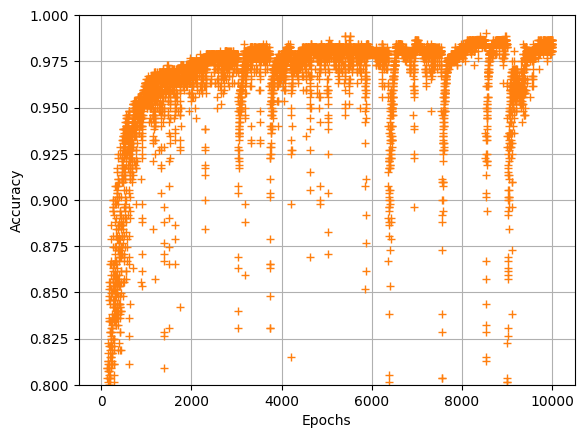

In [13]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

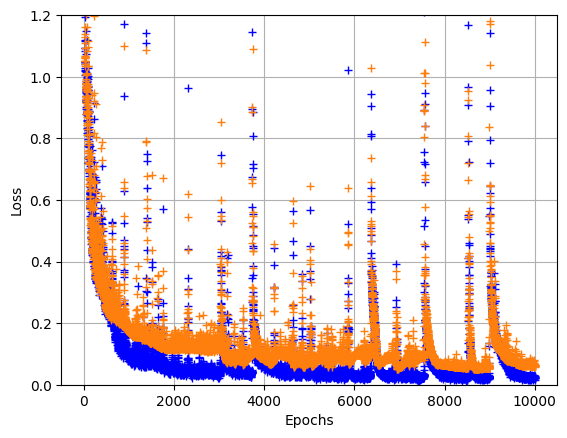

In [14]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [15]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [16]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [17]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9382
Explained variance score: 0.9384
Mean squared error: 0.0100
Accuracy Score: 0.9850
Precision: [0.9738 0.9761 0.9975]
Recall: [0.9930 0.9231 0.9950]
Precision macro: 0.9824402994290672
Recall macro: 0.9703407127424919


### Train quality

In [18]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[705.,   5.,   0.],
       [ 15., 204.,   2.],
       [  4.,   0., 794.]])

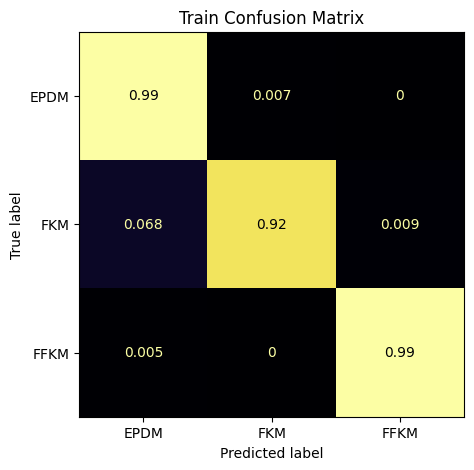

In [19]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

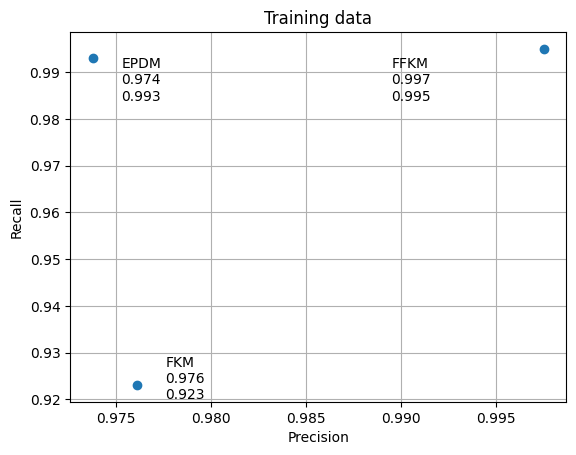

In [20]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [21]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.9992228e-01, 9.5804435e-06, 6.8127338e-05],
       [9.9790502e-01, 1.9249242e-03, 1.7015568e-04],
       [1.5633114e-04, 4.8759364e-07, 9.9984312e-01],
       ...,
       [4.0469125e-08, 3.9134216e-07, 9.9999952e-01],
       [1.0570554e-01, 8.9406580e-01, 2.2869556e-04],
       [2.3226667e-08, 3.1288895e-08, 1.0000000e+00]], dtype=float32)

### Test metrics

In [22]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [23]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9382
Explained variance score: 0.9384
Mean squared error: 0.0100
Accuracy Score: 0.9792
Precision: [0.9570 0.9744 1.0000]
Recall: [0.9944 0.8444 0.9952]
Precision macro: 0.9771160738902674
Recall macro: 0.944691054423486


### Test quality

In [24]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[178.,   1.,   0.],
       [  7.,  38.,   0.],
       [  1.,   0., 208.]])

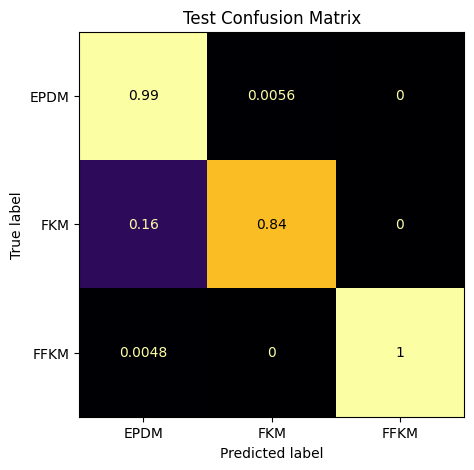

In [25]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

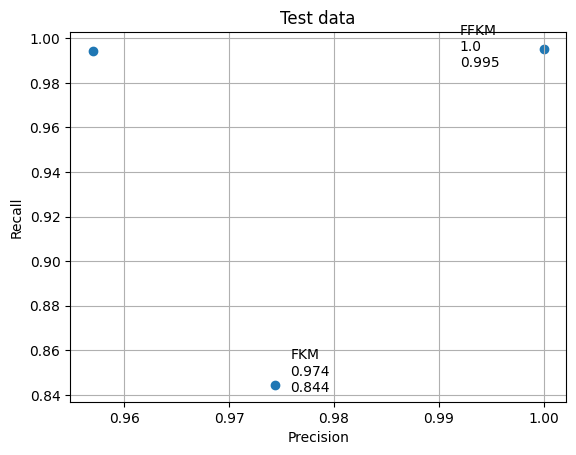

In [26]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [29]:
# torch.save(deepcopy(model.state_dict()), 'RecurrentModel_nodiff.pt')